# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/franciskendrick/flyrank-ml-internship-starter/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

This playbook converts the validated Week-6 model output into a **human-review queue**, not an automated publishing system. The queue is ranked by the Random Forest's observed probability of the Week-5 proxy label, `target_decline`, under the **client-grouped holdout** used in the validation audit.

### Reason-code policy

Reason codes are deliberately transparent and use only signals available at decision time $t$:

| Reason code | Trigger | Suggested action | Why it is reviewable |
|---|---|---|---|
| `HIGH_DECLINE_SCORE` | High model score | **Review / refresh assessment** | Model ranks the page highly for the observed decline proxy |
| `AGING_VISIBLE` | Age $\geq$ 180 days and meaningful historical clicks | **Refresh review** | Consistent with the paper's observed aging/decay pattern |
| `THIN_VISIBLE` | Word count $< 2,000$ and meaningful historical clicks | **Expansion review** | Paper observed that growing pages were longer on average; depth is a directional signal, not a fixed target |
| `HIGH_VALUE_AT_RISK` | Higher historical clicks × CPC proxy | **Prioritize review** | More historical click-equivalent value means reviewer time may have greater potential value |
| `LOW_EVIDENCE` | Low historical demand | **Monitor / defer** | Small volumes make short-term movement noisier |

The action mapping intentionally uses **review**, **refresh assessment**, **expansion review**, and **monitor** rather than automatic edits. The paper recommends refreshing aging pages before decay and expanding thin pages that already earn impressions, while explicitly framing those recommendations as observational decision-support.

### Archetype → action mapping

| Archetype | Typical evidence | Action |
|---|---|---|
| Aging visible | Older page + existing historical demand | Refresh assessment |
| Thin visible | Low word count + existing demand | Expansion assessment |
| High-value decline candidate | High model score + higher click × CPC proxy | Senior review first |
| Low-evidence candidate | High model score but little historical demand | Monitor / validate manually |
| General decline candidate | Model score elevated without a stronger reason code | Review for competing explanations |

The model score is a **ranking signal**, not a claim that a refresh will recover traffic. The paper's 365+ recovery observation is specifically narrower: older pages can recover when updated well; age itself is not evidence of natural recovery.

In [2]:
import os
import json
import numpy as np
import pandas as pd
import duckdb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import average_precision_score, roc_auc_score

# ------------------------------------------------------------
# 1. Authenticate to the warehouse
# ------------------------------------------------------------
try:
    from google.colab import userdata
    hf_token = userdata.get("HF_TOKEN")
except Exception:
    hf_token = os.environ.get("HF_TOKEN")

if not hf_token:
    raise RuntimeError("HF_TOKEN is required in Colab userdata or the environment.")

con = duckdb.connect()
safe_token = hf_token.replace("'", "''")
con.execute(f"CREATE SECRET (TYPE HUGGINGFACE, TOKEN '{safe_token}');")

WAREHOUSE_URI = "hf://datasets/FlyRank/internship-warehouse"
FACT_FEB_PATH = f"{WAREHOUSE_URI}/fact_content_daily_performance/month=2026-02/*.parquet"
FACT_MAR_PATH = f"{WAREHOUSE_URI}/fact_content_daily_performance/month=2026-03/*.parquet"
DIM_CONTENT_PATH = f"{WAREHOUSE_URI}/dim_content.parquet"

# ------------------------------------------------------------
# 2. Build leakage-safe audit data
# ------------------------------------------------------------
fact_union = f"""
SELECT * FROM read_parquet('{FACT_FEB_PATH}', union_by_name=true)
UNION ALL
SELECT * FROM read_parquet('{FACT_MAR_PATH}', union_by_name=true)
"""

query = f"""
WITH fact AS (
    {fact_union}
),
base AS (
    SELECT
        f.report_date,
        f.client_hash_id,
        f.content_hash_id,
        c.word_count,
        c.search_volume,
        c.competition,
        c.cpc,
        c.content_created_date,

        AVG(f.gsc_clicks) OVER (
            PARTITION BY f.client_hash_id, f.content_hash_id
            ORDER BY f.report_date
            ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
        ) AS hist_7d_avg_clicks,

        SUM(f.ga4_total_engagement_sec) OVER (
            PARTITION BY f.client_hash_id, f.content_hash_id
            ORDER BY f.report_date
            ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
        ) AS hist_7d_sum_engagement,

        COUNT(*) OVER (
            PARTITION BY f.client_hash_id, f.content_hash_id
            ORDER BY f.report_date
            ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
        ) AS hist_7d_rows,

        SUM(f.gsc_clicks) OVER (
            PARTITION BY f.client_hash_id, f.content_hash_id
            ORDER BY f.report_date
            ROWS BETWEEN CURRENT ROW AND 6 FOLLOWING
        ) AS target_future_clicks_7d,

        COUNT(*) OVER (
            PARTITION BY f.client_hash_id, f.content_hash_id
            ORDER BY f.report_date
            ROWS BETWEEN CURRENT ROW AND 6 FOLLOWING
        ) AS future_rows_7d

    FROM fact f
    LEFT JOIN read_parquet('{DIM_CONTENT_PATH}') c
      ON f.client_hash_id = c.client_hash_id
     AND f.content_hash_id = c.content_hash_id

    WHERE f.report_date BETWEEN DATE '2026-02-22' AND DATE '2026-03-30'
      AND f.gsc_data_available IS TRUE
      AND f.ga4_data_available IS TRUE
)
SELECT *
FROM base
WHERE report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-24'
  AND hist_7d_rows = 7
  AND future_rows_7d = 7
"""

df = con.sql(query).df()

feature_cols = [
    "word_count", "search_volume", "competition", "cpc",
    "hist_7d_avg_clicks", "hist_7d_sum_engagement"
]

for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[feature_cols] = df[feature_cols].fillna(0)
df["content_created_date"] = pd.to_datetime(df["content_created_date"], errors="coerce")

df["target_decline"] = (
    df["target_future_clicks_7d"] < df["hist_7d_avg_clicks"] * 7
).astype(int)

df["content_age_days"] = (
    pd.to_datetime(df["report_date"]) - df["content_created_date"]
).dt.days

df = df.replace([np.inf, -np.inf], np.nan).dropna(
    subset=feature_cols + ["target_decline", "client_hash_id", "content_hash_id"]
)

if df["target_decline"].nunique() < 2:
    raise RuntimeError("The audit slice has only one target class.")

print("--- PLAYBOOK DATASET ---")
print(f"Rows: {len(df):,}")
print(f"Clients: {df['client_hash_id'].nunique():,}")
print(f"Decision dates: {df['report_date'].min()} to {df['report_date'].max()}")
print(f"Positive rate: {df['target_decline'].mean():.4f}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

--- PLAYBOOK DATASET ---
Rows: 67,559
Clients: 23
Decision dates: 2026-03-01 00:00:00 to 2026-03-24 00:00:00
Positive rate: 0.4833


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

### Intended use

The playbook is intended for a **content strategist, SEO analyst, or editor** who needs a bounded review queue. Its purpose is to answer:

> **Which pages should a human review first for possible refresh, expansion, protection, or monitoring?**

The model ranks pages using signals known before the decision moment $t$. The queue is therefore **decision-support**, not an autonomous content optimizer.

### Decay / refresh insight

The attached FlyRank paper reports that content health peaks around 61–90 days and falls sharply in the 271–365 day bucket. It also reports a higher 365+ health score concentrated among refreshed older pages, while warning that survivor bias makes the 365+ cell narrower to interpret.

The operational translation is therefore **review before the 9–12 month decay zone**, not “refresh every old page.” The paper recommends reviewing pages around 6–9 months and prioritizing pages with proven demand that are beginning to flatten.

### Limits

- The target is a **seven-day future-click decline proxy**, not a business-value or recovery label.
- The client-grouped validation result is based on a limited holdout; it is evidence about this audit slice, not a production guarantee.
- A high score does **not** mean a page will decline, and a refresh does **not** have an established causal payoff.
- `word_count < 2,000` is a review heuristic, not a universal content-length requirement. The paper explicitly says quality depth is preferable to padding and that the data does not establish a page-level ideal duration.
- The queue contains pseudonymous IDs and is for internal analysis only. No client names, URLs, titles, or private queries are exported.
- The playbook does not diagnose Google algorithm changes, content quality in a semantic sense, or revenue impact.

### Cost/value thinking

Historical **clicks × CPC** is used only as a click-equivalent value proxy. The paper explicitly recommends this formulation instead of impressions × CPC and warns that it is not booked revenue.

Reviewer capacity should therefore favor high-ranked pages with stronger historical value proxies when two candidates have similar evidence. This is a prioritization heuristic, not an expected ROI calculation.


In [3]:
# ------------------------------------------------------------
# 3. Honest client-group validation
# ------------------------------------------------------------
X = df[feature_cols]
y = df["target_decline"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=42,
)

train_idx, test_idx = next(
    gss.split(X, y, groups=df["client_hash_id"])
)

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    n_jobs=-1,
)

model.fit(X.iloc[train_idx], y.iloc[train_idx])

proba = model.predict_proba(X.iloc[test_idx])
positive_idx = list(model.classes_).index(1)
prob_decline = proba[:, positive_idx]

queue = df.iloc[test_idx].copy()
queue["prob_decline"] = prob_decline
queue = queue.sort_values("prob_decline", ascending=False).reset_index(drop=True)
queue["rank"] = np.arange(1, len(queue) + 1)

# Top-K validation metrics.
k = min(50, len(queue))
top_k = queue.head(k)
precision_at_50 = top_k["target_decline"].mean()
avg_precision = average_precision_score(y.iloc[test_idx], prob_decline)
roc_auc = roc_auc_score(y.iloc[test_idx], prob_decline)

# Historical click-equivalent value proxy.
queue["hist_7d_clicks_proxy"] = queue["hist_7d_avg_clicks"] * 7
queue["click_value_proxy"] = (
    queue["hist_7d_clicks_proxy"] * queue["cpc"].fillna(0)
)

print("--- VALIDATED QUEUE ---")
print(f"Holdout clients: {queue['client_hash_id'].nunique():,}")
print(f"Holdout rows: {len(queue):,}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"Average Precision: {avg_precision:.4f}")
print(f"Precision@50: {precision_at_50:.4f}")

--- VALIDATED QUEUE ---
Holdout clients: 7
Holdout rows: 1,135
ROC AUC: 0.7223
Average Precision: 0.5647
Precision@50: 0.5200


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

### Required human review

Before any content change, the reviewer should check:

1. **Search demand:** Is the page still receiving meaningful search activity?
2. **Intent fit:** Does the current page still answer the underlying intent?
3. **Freshness:** Has the topic, product, regulation, or recommendation materially changed?
4. **Existing strengths:** Does the page already have useful visibility or engagement worth protecting?
5. **Competitive context:** Is the observed movement plausibly explained by broader market or SERP movement?
6. **Content scope:** Would expansion add missing information, examples, definitions, comparisons, or evidence rather than padding?
7. **Business importance:** Does the page have strategic or commercial importance that the model does not observe?

### No-go list

The following should **not** be automated by this playbook:

- publishing, deleting, or rewriting content;
- changing titles/meta descriptions without editorial review;
- deciding that a page is “bad content”;
- declaring that a refresh will recover traffic;
- diagnosing a Google algorithm update from this queue;
- merging or pruning pages without a separate overlap/cannibalization review;
- making client-level or revenue-level decisions from pseudonymous page scores;
- using the model score as a substitute for human review.

The internship guide specifically warns against treating decline as a guarantee that a refresh will pay off and requires the reason behind a high score to remain visible.

### Review decision policy

| Queue state | Human action |
|---|---|
| Top-ranked + strong reason code | Review first |
| Top-ranked + low evidence | Validate demand before editing |
| Aging + visible | Check freshness and refresh history |
| Thin + visible | Check missing subtopics before expansion |
| High-value proxy + decline score | Prioritize if reviewer capacity is limited |
| No clear evidence | Monitor rather than force an action |

In [4]:
# ------------------------------------------------------------
# 4. Reason codes and action mapping
# ------------------------------------------------------------

# Thresholds are policy choices, not universal truths.
MEANINGFUL_CLICK_THRESHOLD = 1.0
THIN_WORD_THRESHOLD = 2000
AGING_DAYS = 180
DECAY_REVIEW_DAYS = 270
HIGH_SCORE_QUANTILE = 0.80

score_cutoff = queue["prob_decline"].quantile(HIGH_SCORE_QUANTILE)

queue["reason_codes"] = ""
queue["suggested_action"] = "Monitor"
queue["archetype"] = "General decline candidate"

for i, row in queue.iterrows():
    codes = []

    if row["prob_decline"] >= score_cutoff:
        codes.append("HIGH_DECLINE_SCORE")

    if (
        row["content_age_days"] >= AGING_DAYS
        and row["hist_7d_clicks_proxy"] >= MEANINGFUL_CLICK_THRESHOLD
    ):
        codes.append("AGING_VISIBLE")

    if (
        row["word_count"] < THIN_WORD_THRESHOLD
        and row["hist_7d_clicks_proxy"] >= MEANINGFUL_CLICK_THRESHOLD
    ):
        codes.append("THIN_VISIBLE")

    if row["click_value_proxy"] >= queue["click_value_proxy"].quantile(0.75):
        codes.append("HIGH_VALUE_AT_RISK")

    if row["hist_7d_clicks_proxy"] < MEANINGFUL_CLICK_THRESHOLD:
        codes.append("LOW_EVIDENCE")

    if not codes:
        codes.append("GENERAL_REVIEW")

    # Action mapping gives precedence to specific evidence.
    if "LOW_EVIDENCE" in codes:
        action = "Monitor / validate demand"
        archetype = "Low-evidence candidate"
    elif "AGING_VISIBLE" in codes and "THIN_VISIBLE" in codes:
        action = "Refresh + expansion assessment"
        archetype = "Aging thin visible page"
    elif "AGING_VISIBLE" in codes:
        action = "Refresh assessment"
        archetype = "Aging visible page"
    elif "THIN_VISIBLE" in codes:
        action = "Expansion assessment"
        archetype = "Thin visible page"
    elif "HIGH_VALUE_AT_RISK" in codes:
        action = "Senior review first"
        archetype = "Higher-value decline candidate"
    else:
        action = "Review for competing explanations"
        archetype = "General decline candidate"

    queue.at[i, "reason_codes"] = ";".join(codes)
    queue.at[i, "suggested_action"] = action
    queue.at[i, "archetype"] = archetype

# Confidence is deliberately ordinal and tied to evidence, not probability calibration.
queue["confidence_label"] = np.select(
    [
        queue["prob_decline"] >= queue["prob_decline"].quantile(0.90),
        queue["prob_decline"] >= score_cutoff,
    ],
    ["Higher-ranked", "Moderately-ranked"],
    default="Lower-ranked",
)

# Public-safe queue view: pseudonymous identifiers only.
queue_export_cols = [
    "rank", "client_hash_id", "content_hash_id", "report_date",
    "prob_decline", "confidence_label", "archetype",
    "suggested_action", "reason_codes", "content_age_days",
    "word_count", "search_volume", "competition", "cpc",
    "hist_7d_avg_clicks", "hist_7d_sum_engagement",
    "hist_7d_clicks_proxy", "click_value_proxy", "target_decline"
]

print("--- TOP 20 ACTION QUEUE ---")
print(
    queue[queue_export_cols].head(20).to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

print("\n--- ACTION COUNTS ---")
print(queue["suggested_action"].value_counts().to_string())

--- TOP 20 ACTION QUEUE ---
 rank          client_hash_id          content_hash_id report_date  prob_decline confidence_label                      archetype     suggested_action                                       reason_codes  content_age_days  word_count  search_volume  competition    cpc  hist_7d_avg_clicks  hist_7d_sum_engagement  hist_7d_clicks_proxy  click_value_proxy  target_decline
    1 client_b10cb2997d0c7c86 content_06dcc81394435cf5  2026-03-18        0.6200    Higher-ranked Higher-value decline candidate  Senior review first              HIGH_DECLINE_SCORE;HIGH_VALUE_AT_RISK               169        4561              0       0.0000 0.0000              2.1429                716.0000               15.0000             0.0000               1
    2 client_b10cb2997d0c7c86 content_06dcc81394435cf5  2026-03-17        0.6181    Higher-ranked Higher-value decline candidate  Senior review first              HIGH_DECLINE_SCORE;HIGH_VALUE_AT_RISK               168        4561        

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

Monitoring should focus on whether the queue remains useful for its intended human-review task.

### Light monitoring

| Signal | Trigger | Response |
|---|---|---|
| Precision@50 | Falls materially below the validated baseline on a later labeled window | Investigate feature drift, label drift, and split stability |
| Average Precision | Sustained decline across later validation windows | Review model and feature definitions |
| Client coverage | New clients or materially changed client mix | Re-run grouped validation before relying on the queue |
| Feature drift | Large shift in age, word count, historical clicks, or CPC distributions | Inspect data pipeline and reconsider thresholds |
| Reason-code mix | One reason code dominates unexpectedly | Review threshold policy and feature availability |
| Review acceptance | Humans frequently reject top-ranked recommendations | Inspect failure examples and revise action mapping |

### Retrain / rebuild triggers

A retrain should be considered when:

- a new warehouse release materially changes the observed distribution;
- the labeled future window has moved far enough that the original training period no longer represents current conditions;
- grouped validation shows sustained deterioration;
- feature definitions or source availability change;
- the operational action mapping changes substantially.

Retraining should **not** be triggered merely because a single week's metric moves. A later audit should use multiple time windows or repeated grouped splits before changing the model.

### Success measure

The primary operational metric remains **Precision@K**, because the playbook is a limited review queue. The paper and internship guide both emphasize ranked review outputs rather than generic classification accuracy.

The downstream business question is different: whether reviewed actions actually improve outcomes. That requires a prospective comparison or experiment; this notebook does not establish causal lift.

In [5]:
# ------------------------------------------------------------
# 4. Basic monitoring receipt
# ------------------------------------------------------------
monitor = {
    "precision_at_50": float(precision_at_50),
    "average_precision": float(avg_precision),
    "roc_auc": float(roc_auc),
    "test_clients": int(queue["client_hash_id"].nunique()),
    "queue_rows": int(len(queue)),
    "action_mix": queue["suggested_action"].value_counts().to_dict(),
}

print("--- MONITORING RECEIPT ---")
print(json.dumps(monitor, indent=2))

print("\nRecommended trigger review:")
print("- Recheck Precision@50 and Average Precision on later labeled windows.")
print("- Re-run client-group validation when client mix or feature distributions materially change.")
print("- Inspect reason-code mix and human acceptance before changing thresholds.")

--- MONITORING RECEIPT ---
{
  "precision_at_50": 0.52,
  "average_precision": 0.5647008158320508,
  "roc_auc": 0.7223146796431468,
  "test_clients": 7,
  "queue_rows": 1135,
  "action_mix": {
    "Refresh assessment": 465,
    "Senior review first": 240,
    "Monitor / validate demand": 233,
    "Refresh + expansion assessment": 159,
    "Expansion assessment": 38
  }
}

Recommended trigger review:
- Recheck Precision@50 and Average Precision on later labeled windows.
- Re-run client-group validation when client mix or feature distributions materially change.
- Inspect reason-code mix and human acceptance before changing thresholds.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to `work/outputs/` — your paper builds on these files.*

The notebook generates three artifacts:

1. `work/outputs/w07_ranked_action_queue.csv` — regenerated pseudonymous review queue; intentionally kept out of git by the project's data leak guard.
2. `work/outputs/w07_validation_metrics.json` — compact validation receipt containing the metrics and evaluation window used by the paper.
3. `work/figures/w07_action_mix.png` — reusable figure showing the distribution of suggested review actions.

The queue is regenerated rather than committed so the repository does not contain row-level warehouse data. The metrics JSON and figure are small paper-facing artifacts.

### Paper-ready interpretation

> The playbook converts an observed future-click decline ranking into a human-reviewed queue with explicit reason codes. Under the client-grouped validation used in the audit, the queue's measured Precision@50 is reported as a directional decision-support metric. The queue does not automate content changes and does not establish that refreshing a selected page will cause recovery.

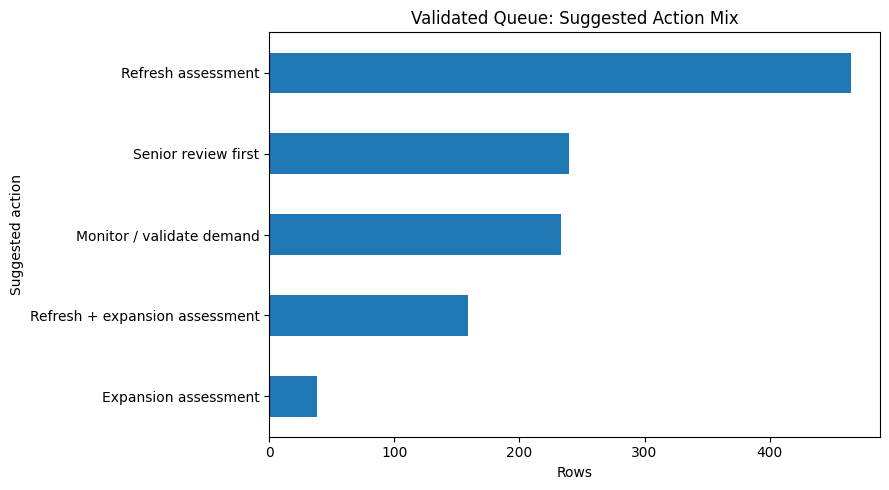

--- EXPORTS ---
Queue CSV      : work/outputs/w07_ranked_action_queue.csv
Metrics JSON   : work/outputs/w07_validation_metrics.json
Reusable figure: work/figures/w07_action_mix.png

--- METRICS RECEIPT ---
{
  "validation_split": "client_group_holdout",
  "random_state": 42,
  "test_clients": 7,
  "test_rows": 1135,
  "roc_auc": 0.7223146796431468,
  "average_precision": 0.5647008158320508,
  "precision_at_50": 0.52,
  "decision_date_min": "2026-03-01 00:00:00",
  "decision_date_max": "2026-03-24 00:00:00",
  "target": "future 7-day clicks < prior 7-day average clicks x 7",
  "note": "Directional decision-support metric; not causal recovery or production ROI."
}


In [6]:
# ------------------------------------------------------------
# 5. Export queue, metrics receipt, and reusable figure
# ------------------------------------------------------------
from pathlib import Path
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("work/outputs")
FIGURE_DIR = Path("work/figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# The queue CSV is intentionally generated but not intended for git.
queue_path = OUTPUT_DIR / "w07_ranked_action_queue.csv"
queue[queue_export_cols].to_csv(queue_path, index=False)

# Metrics JSON is a small committed receipt for the paper.
metrics = {
    "validation_split": "client_group_holdout",
    "random_state": 42,
    "test_clients": int(queue["client_hash_id"].nunique()),
    "test_rows": int(len(queue)),
    "roc_auc": float(roc_auc),
    "average_precision": float(avg_precision),
    "precision_at_50": float(precision_at_50),
    "decision_date_min": str(queue["report_date"].min()),
    "decision_date_max": str(queue["report_date"].max()),
    "target": "future 7-day clicks < prior 7-day average clicks x 7",
    "note": "Directional decision-support metric; not causal recovery or production ROI.",
}

metrics_path = OUTPUT_DIR / "w07_validation_metrics.json"
metrics_path.write_text(
    json.dumps(metrics, indent=2),
    encoding="utf-8",
)

# Reusable figure: action mix in the validated queue.
action_counts = queue["suggested_action"].value_counts().sort_values(ascending=True)

plt.figure(figsize=(9, 5))
action_counts.plot(kind="barh")
plt.title("Validated Queue: Suggested Action Mix")
plt.xlabel("Rows")
plt.ylabel("Suggested action")
plt.tight_layout()
figure_path = FIGURE_DIR / "w07_action_mix.png"
plt.savefig(figure_path, dpi=160)
plt.show()

print("--- EXPORTS ---")
print(f"Queue CSV      : {queue_path}")
print(f"Metrics JSON   : {metrics_path}")
print(f"Reusable figure: {figure_path}")

print("\n--- METRICS RECEIPT ---")
print(json.dumps(metrics, indent=2))

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.